# Data Analysis for READ-MAS Agents

This notebook contains all the data analysis and EDA performed on the experiment datasets. It consists of:
- a section to import libraries and define constants that include mapping dictionaries and lists for metrics, column renaming, and file mappings per RQ and EDA requirements.
- a section for reusable helper functions to load experiment datasets, prepare group data frames for ANOVA analysis, and perform the ANOVA and post hoc tests
- multiple sections for ANOVA analysis of the RQs
- EDA for benchmarking
- EDA for training and evaluation of the individual agents

## Import Libraries and Define Constants

In [97]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import  pingouin 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# The parent path to the benchmark experiment runs
EXPERIMENT_PATH = '../../benchmark_runs/'

# Column renames for LLM as a Judge benchmark runs
RENAME_BENCHMARK = {
  'runs/benchmark_runs/metrics.json:agent':                    'agent',
  'runs/benchmark_runs/metrics.json:model':                    'model',
  'runs/benchmark_runs/metrics.json:rag':                      'rag',
  'runs/benchmark_runs/metrics.json:DesignAccuracy [GEval]':   'design_accuracy',
  'DesignAccuracy [GEval]':                                    'design_accuracy',
  'runs/benchmark_runs/metrics.json:faithfulness (ragas)':     'ragas_faithfulness',
  'runs/benchmark_runs/metrics.json:RAGAS':                    'ragas',
}
# Columns to keep in the benchmark runs data frame
KEEP_BENCHMARK = ['agent', 'model', 'rag', 'design_accuracy', 'ragas_faithfulness', 'ragas']

# Column renames for code benchmark runs
RENAME_CODE_BENCHMARK = {
  'code.agent_name':                                          'agent',
  'code.model':                                               'model',
  'code.rag':                                                 'rag',
  'pass@1':                                                   'pass_at_1',
  'pass@1plus':                                               'pass_at_1plus',
  'code.dataset':                                             'benchmark',
  'runs/code_benchmark_runs/metrics.json:pass@1':             'pass_at_1',
  'runs/code_benchmark_runs/metrics.json:pass@1plus':         'pass_at_1plus',
}

# Columns to keep for code benchmark runs
KEEP_CODE_BENCHMARK = ['agent', 'model', 'rag', 'pass_at_1', 'pass_at_1plus', 'benchmark']

# Column renames for plain LLM code benchmark runs
RENAME_LLM_BENCHMARK = {
  'runs/llm_benchmark_runs/metrics.json:model':                     'model',
  'runs/llm_benchmark_runs/metrics.json:pass@1':                    'pass_at_1',
  'runs/llm_benchmark_runs/metrics.json:pass@1plus':                'pass_at_1plus',
  'runs/llm_benchmark_runs/metrics.json:benchmark':                 'benchmark',
}

# Columns to keep for plain LLM code benchmark runs
KEEP_LLM_BENCHMARK = ['agent', 'model', 'pass_at_1', 'pass_at_1plus', 'benchmark']

# LLM as a Judge and RAGAS metrics
BENCHMARK_METRICS = ['design_accuracy', 'ragas_faithfulness', 'ragas']

# HumanEval and MBPP metrics for code benchmarking
CODE_METRICS = ['pass_at_1', 'pass_at_1plus']

# Metrics without RAGAS for RQ5
NO_RAGAS_METRICS = ['design_accuracy']

# Constants for experiment groups corresponding to the Research Questions
# Mapping of custom benchmarks and metrics
BENCHMARK_COL_METRICS_MAP = {
  'benchmark': {
    'rename_cols': RENAME_BENCHMARK,
    'keep_cols': KEEP_BENCHMARK,
    'metrics': BENCHMARK_METRICS
  }
}

# Mapping of custom benchmarks and metrics for NO RAGAS use case
NO_RAGAS_BENCHMARK_COL_METRICS_MAP = {
  'benchmark': {
    'rename_cols': RENAME_BENCHMARK,
    'keep_cols': KEEP_BENCHMARK,
    'metrics': NO_RAGAS_METRICS
  }
}

# Mapping of coding benchmarks and metrics
CODE_BENCHMARK_COL_METRICS_MAP = {
  'humaneval': {
    'rename_cols': RENAME_CODE_BENCHMARK,
    'keep_cols': KEEP_CODE_BENCHMARK,
    'metrics': CODE_METRICS    
  },
  'mbpp': {
    'rename_cols': RENAME_CODE_BENCHMARK,
    'keep_cols': KEEP_CODE_BENCHMARK,
    'metrics': CODE_METRICS    
  }
}

# Code benchmark mappings with no RAG for LLM vs agent comparison (RQ4)
CODE_LLM_COL_METRICS_MAP = {
  'humaneval': {
    'rename_cols': RENAME_CODE_BENCHMARK | RENAME_LLM_BENCHMARK,
    'keep_cols': KEEP_LLM_BENCHMARK,
    'metrics': CODE_METRICS    
  },
  'mbpp': {
    'rename_cols': RENAME_CODE_BENCHMARK | RENAME_LLM_BENCHMARK,
    'keep_cols': KEEP_LLM_BENCHMARK,
    'metrics': CODE_METRICS    
  }
}

# RQ1: Gemini - Custom benchmark, HumanEval and MBPP code benchmark experiment datasets
RQ1_BENCHMARK_FILES_GEMINI = {
    'benchmark': ('single_agent_benchmark_gemini.csv',
                  'read_agent_benchmark_gemini.csv'),
    'humaneval': ('single_agent_code_benchmark_humaneval_gemini.csv',
                'read_agent_code_benchmark_humaneval_gemini.csv'),
    'mbpp':      ('single_agent_code_benchmark_mbpp_gemini.csv',
                'read_agent_code_benchmark_mbpp_gemini.csv'),
}

# RQ1: GPT-5-mini - Custom benchmark, HumanEval and MBPP code benchmark experiment datasets
RQ1_BENCHMARK_FILES_OPENAI = {
    'benchmark': ('single_agent_benchmark_openai.csv', 'read_agent_benchmark_openai.csv'),
    'humaneval': ('single_agent_code_benchmark_humaneval_openai.csv',
                'read_agent_code_benchmark_humaneval_openai.csv'),
    'mbpp': ('single_agent_code_benchmark_mbpp_openai.csv',
              'read_agent_code_benchmark_mbpp_openai.csv')
}

# Columns and metrics map combining custom and code benchmarks.
FULL_COL_METRICS_MAP = BENCHMARK_COL_METRICS_MAP | CODE_BENCHMARK_COL_METRICS_MAP

# No RAGAS columns and metrics map combining custom and code benchmarks.
NO_RAGAS_COL_METRICS_MAP = NO_RAGAS_BENCHMARK_COL_METRICS_MAP | CODE_BENCHMARK_COL_METRICS_MAP

# Numeric columns (used in EDA data frames)
NUMERIC_COLS = ['pass_at_1', 'pass_at_1plus', 'design_accuracy', 'ragas_faithfulness', 'ragas']

# RQ2: Custom benchmark, HumanEval and MBPP code benchmark experiment datasets
RQ2_BENCHMARK_FILES = {
    'benchmark': ('read_agent_benchmark_claude.csv',
                  'read_agent_benchmark_gemini.csv',
                  'read_agent_benchmark_ollama.csv',
                  'read_agent_benchmark_openai.csv'),
    'humaneval': ('read_agent_code_benchmark_humaneval_claude.csv',
                'read_agent_code_benchmark_humaneval_gemini.csv',
                'read_agent_code_benchmark_humaneval_ollama.csv',
                'read_agent_code_benchmark_humaneval_openai.csv'),
    'mbpp':      ('read_agent_code_benchmark_mbpp_claude.csv',
                'read_agent_code_benchmark_mbpp_gemini.csv',
                'read_agent_code_benchmark_mbpp_ollama.csv',
                'read_agent_code_benchmark_mbpp_openai.csv'),
}

# RQ4: Custom benchmark, HumanEval and MBPP code benchmark experiment datasets
RQ4_BENCHMARK_FILES = {
    'humaneval': ('read_agent_code_benchmark_humaneval_claude.csv',
                'llm_code_benchmark_humaneval_claude.csv'),
    'mbpp':      ('read_agent_code_benchmark_mbpp_claude.csv',
                'llm_code_benchmark_mbpp_claude.csv'),
}

# RQ5: Custom benchmark, HumanEval and MBPP code benchmark experiment datasets
RQ5_BENCHMARK_FILES = {
    'benchmark': ('read_agent_benchmark_gemini_rag.csv',
                  'read_agent_benchmark_gemini_no_rag.csv')
}

# RQ5: Custom benchmark experiments using the DevBench index for RAG
RQ5_INDEX_BENCHMARK_FILES = {
    'benchmark': ('read_agent_benchmark_gemini_index.csv',
                  'read_agent_benchmark_gemini_no_rag.csv'),
}

# EDA file groups: all benchmark and code benchmark files for exploratory analysis
EDA_CODE_BENCHMARK_FILES = {
  'humaneval': (
    'read_agent_code_benchmark_humaneval_claude.csv',
    'read_agent_code_benchmark_humaneval_gemini.csv',
    'read_agent_code_benchmark_humaneval_ollama.csv',
    'read_agent_code_benchmark_humaneval_openai.csv',
    'single_agent_code_benchmark_humaneval_gemini.csv',
    'single_agent_code_benchmark_humaneval_openai.csv',
  ),
  'mbpp': (
    'read_agent_code_benchmark_mbpp_claude.csv',
    'read_agent_code_benchmark_mbpp_gemini.csv',
    'read_agent_code_benchmark_mbpp_ollama.csv',
    'read_agent_code_benchmark_mbpp_openai.csv',
    'single_agent_code_benchmark_mbpp_gemini.csv',
    'single_agent_code_benchmark_mbpp_openai.csv',
  ),
}

EDA_LLM_BENCHMARK_FILES = {
  'humaneval': ('llm_code_benchmark_humaneval_claude.csv',),
  'mbpp':      ('llm_code_benchmark_mbpp_claude.csv',),
}

EDA_DESIGN_BENCHMARK_FILES = {
  'benchmark': (
    'read_agent_benchmark_claude.csv',
    'read_agent_benchmark_gemini.csv',
    'read_agent_benchmark_gemini_no_rag.csv',
    'read_agent_benchmark_ollama.csv',
    'read_agent_benchmark_openai.csv',
    'single_agent_benchmark_gemini.csv',
  ),
}

EDA_DESIGN_BENCHMARK_RAG_FILES = {
  'benchmark': (
    'read_agent_benchmark_gemini_rag.csv',
    'read_agent_benchmark_gemini_no_rag.csv',
  )
}

EDA_DESIGN_BENCHMARK_RAG_SPECIFIC_FILES = {
  'benchmark': (
    'read_agent_benchmark_gemini_index.csv',
    'read_agent_benchmark_gemini_no_rag.csv',
  )
}



## Helper Functions for Experiment Data Loading and Perform ANOVA

Helper functions

In [73]:
def load_experiment_dataset(filename: str, rename_cols: dict[str, str], keep_cols: list[str]) -> pd.DataFrame:
    """This function loads an experiment data in CSV format into a data frame, filters out the baselines, renames the columns, and keeps only the columns needed for the analysis.
    
    Args:
        filename: the relative path to the experiment dataset
        rename_cols: a dict to rename the dataset columns
        keep_cols: the columns to keep in the data frame
        
    Returns:
        A Pandas data frame
    """
    df = pd.read_csv(EXPERIMENT_PATH + filename)
    df = df[df['typ'].isin(['branch_base', 'branch_commit'])]
    df = df.rename(columns=rename_cols)
    
     # Set agent to llm for LLM benchmark datasets
    if 'agent' not in df.columns:
      df['agent'] = 'llm'

    return df[keep_cols]


In [74]:
def get_group_dfs(group_files: dict[str, tuple[str, ...]], group_col_metrics_map: dict[str, dict[str, str]]) -> list[dict]:
  """This function prepares a list of dictionaries containing sets of data frames and associated metrics that are necessary for a particular ANOVA test or EDA analysis.
  
  Args:
    group_files: a dictionary of experiment files grouped by benchmarks used for a specific test or EDA
    group_col_metrics_map: a map of field renamings and metrics for a required test or EDA
    
  Returns:
    a list of dictionaries containing group data frames and metrics grouped by benchmarks
  
  """
  group_dfs = []
  for benchmark, files in group_files.items():
    config = group_col_metrics_map[benchmark]
    rename_cols = config['rename_cols']
    keep_cols = config['keep_cols']
    metrics = config['metrics']
    
    df_list = [
        load_experiment_dataset(f, rename_cols, keep_cols) 
        for f in files
    ]
    
    group_df = pd.concat(df_list, ignore_index=True)
        
    group_dfs.append({'benchmark': benchmark, 'group_df': group_df, 'metrics': metrics})

  return group_dfs

In [75]:
def perform_anova(benchmark: str, group_df: pd.DataFrame, metrics: list[str], group: str):
    """This function performs ANOVA assumption checks, ANOVA, and post hoc tests 
    and displays results as Markdown tables for dissertation manuscript use.
    
    Args:
        benchmark: the benchmark for which the ANOVA is performed
        group_df: the combined data frame for a particular hypothesis test
        metrics: the list of metrics serving as a target for the ANOVA tests
        group: the categorical variable ANOVA compares
    """
    
    # Explicit coercion of metric values to numeric since LLM file stores pass values as strings, which causes errors in pingouin.
    group_df = group_df.copy()
    for metric in metrics:
        group_df[metric] = pd.to_numeric(group_df[metric], errors='coerce')
    
    print(f"\n# Benchmark: {benchmark}")
    
    for metric in metrics:
        print(f"\n## Metric: {metric}")
        
        # ANOVA Assumption checks
        norm = pingouin.normality(data=group_df, dv=metric, group=group, method='shapiro')
        print("\n#### Shapiro-Wilk Normality Test")
        print(f"*p > 0.05 indicates normality*")
        print(norm[['W', 'pval', 'normal']].to_markdown(index=False))
        
        eq_var = pingouin.homoscedasticity(data=group_df, dv=metric, group=group, method='levene')
        print("\n#### Levene Homoscedasticity Test")
        print(f"*p > 0.05 indicates equal variances*")
        print(eq_var[['W', 'pval', 'equal_var']].to_markdown(index=False))
        
        normal = norm['normal'].all()
        equal_var = eq_var['equal_var'].iloc[0]
        
        # ANOVA/Kruskal-Wallis tests based on assumption check results
        if not normal:
            kw = pingouin.kruskal(data=group_df, dv=metric, between=group)
            print(f"\n#### Kruskal-Wallis Test (Non-Parametric)")
            print(kw.to_markdown(index=False))
            
            # Convert series to dataframe for markdown formatting
            medians = group_df.groupby(group)[metric].median().reset_index()
            medians.columns = [group, 'Median']
            print(f"\n#### Group Medians")
            print(medians.to_markdown(index=False))
            
        elif not equal_var:
            aov = pingouin.welch_anova(data=group_df, dv=metric, between=group)
            print(f"\n#### Welch's ANOVA")
            print(aov.to_markdown(index=False))
            print(f"\n**Summary:** F({aov.iloc[0]['ddof1']:.0f}, {aov.iloc[0]['ddof2']:.2f}) = {aov.iloc[0]['F']:.4f}, p = {aov.iloc[0]['p_unc']:.4f}")
            
            gh = pingouin.pairwise_gameshowell(data=group_df, dv=metric, between=group)
            print(f"\n#### Games-Howell Post Hoc Test")
            print(gh.to_markdown(index=False))
            
        else:
            aov = pingouin.anova(data=group_df, dv=metric, between=group, detailed=True)
            print(f"\n#### One-way ANOVA")
            print(aov.to_markdown(index=False))
            print(f"\n**Summary:** F({aov.iloc[0]['DF']}, {aov.iloc[1]['DF']}) = {aov.iloc[0]['F']:.4f}, p = {aov.iloc[0]['p_unc']:.4f}")
            
            tukey = pingouin.pairwise_tukey(data=group_df, dv=metric, between=group)
            print(f"\n#### Tukey HSD Post Hoc Test")
            print(tukey.to_markdown(index=False))

## Load Experiment Datasets

Load the experiment datasets and filter the experiments.

In [98]:
# RQ1 grouped datasets - Gemini
rq1_group_gemini_dfs = get_group_dfs(RQ1_BENCHMARK_FILES_GEMINI, FULL_COL_METRICS_MAP)

for group in rq1_group_gemini_dfs:
  print(f"Benchmark {group['benchmark']}  Metrics {group['metrics']}\n")
  print(f"RQ1 combined group dataset (Gemini) for {group['benchmark']}: \n")
  print(group['group_df'].to_markdown(index=False))
  print("\n\n")

# RQ1 grouped datasets - OpenAI
rq1_group_openai_dfs = get_group_dfs(RQ1_BENCHMARK_FILES_OPENAI, FULL_COL_METRICS_MAP)

for group in rq1_group_openai_dfs:
  print(f"RQ1 combined group dataset (OpenAI) for {group['benchmark']}: \n")
  print(group['group_df'].to_markdown(index=False))
  print("\n\n")

# RQ2 grouped datasets
rq2_group_dfs = get_group_dfs(RQ2_BENCHMARK_FILES, FULL_COL_METRICS_MAP)

for group in rq2_group_dfs:
  print(f"RQ2 combined group dataset for {group['benchmark']}: \n")
  print(group['group_df'].to_markdown(index=False))
  print("\n\n")
  
# RQ4 grouped datasets
rq4_group_dfs = get_group_dfs(RQ4_BENCHMARK_FILES, CODE_LLM_COL_METRICS_MAP)

for group in rq4_group_dfs:
  print(f"RQ4 combined group dataset for {group['benchmark']}: \n")
  print(group['group_df'].to_markdown(index=False))
  print("\n\n")
  
# RQ5 grouped datasets
rq5_group_dfs = get_group_dfs(RQ5_BENCHMARK_FILES, NO_RAGAS_COL_METRICS_MAP)

for group in rq5_group_dfs:
  print(f"RQ5 combined group dataset for {group['benchmark']}: \n")
  print(group['group_df'].to_markdown(index=False))
  print("\n\n")
  
# RQ5 grouped datasets for RAG using DevBench data
rq5_devbench_group_dfs = get_group_dfs(RQ5_INDEX_BENCHMARK_FILES, NO_RAGAS_COL_METRICS_MAP)

for group in rq5_devbench_group_dfs:
  print(f"RQ5 combined group dataset for {group['benchmark']}: \n")
  print(group['group_df'].to_markdown(index=False))
  print("\n\n")

# EDA grouped datasets
eda_code_group_dfs   = get_group_dfs(EDA_CODE_BENCHMARK_FILES, CODE_BENCHMARK_COL_METRICS_MAP)
eda_llm_group_dfs    = get_group_dfs(EDA_LLM_BENCHMARK_FILES, CODE_LLM_COL_METRICS_MAP)
eda_design_group_dfs = get_group_dfs(EDA_DESIGN_BENCHMARK_FILES, BENCHMARK_COL_METRICS_MAP)
eda_design_rag_group_dfs = get_group_dfs(EDA_DESIGN_BENCHMARK_RAG_FILES, BENCHMARK_COL_METRICS_MAP)
eda_design_rag_specific_group_dfs = get_group_dfs(EDA_DESIGN_BENCHMARK_RAG_SPECIFIC_FILES, BENCHMARK_COL_METRICS_MAP)

Benchmark benchmark  Metrics ['design_accuracy', 'ragas_faithfulness', 'ragas']

RQ1 combined group dataset (Gemini) for benchmark: 

| agent        | model            | rag   |   design_accuracy |   ragas_faithfulness |   ragas |
|:-------------|:-----------------|:------|------------------:|---------------------:|--------:|
| single_agent | gemini-2.5-flash | True  |             0.797 |                0.91  |   0.697 |
| single_agent | gemini-2.5-flash | True  |             0.84  |                0.703 |   0.652 |
| single_agent | gemini-2.5-flash | True  |             0.882 |                0.846 |   0.67  |
| single_agent | gemini-2.5-flash | True  |             0.828 |                0.894 |   0.675 |
| single_agent | gemini-2.5-flash | True  |             0.829 |                0.816 |   0.639 |
| single_agent | gemini-2.5-flash | True  |             0.898 |                0.807 |   0.651 |
| single_agent | gemini-2.5-flash | True  |             0.922 |                0.886 |   0

## RQ1: Compare Single and Multi Agents

Does using multiple agents compared to a single agent improve the performance of the generated code, as measured by the HumanEval and MBPP benchmarks, and the design, as measured by custom LLM-as-a-Judge and RAGAS faithfulness metrics?

### Single vs Multi-agent using Gemini-2.5-Flash

In [77]:
# RQ1 ANOVA analysis for experiments that used Gemini-2.5-flash model
for group in rq1_group_gemini_dfs:
  perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'agent')


# Benchmark: benchmark

## Metric: design_accuracy

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |     pval | normal   |
|---------:|---------:|:---------|
| 0.918068 | 0.341123 | True     |
| 0.947497 | 0.638994 | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|      W |        pval | equal_var   |
|-------:|------------:|:------------|
| 19.219 | 0.000357955 | False       |

#### Welch's ANOVA
| Source   |   ddof1 |   ddof2 |       F |    p_unc |      np2 |
|:---------|--------:|--------:|--------:|---------:|---------:|
| agent    |       1 | 11.0165 | 7.73398 | 0.017849 | 0.300536 |

**Summary:** F(1, 11.02) = 7.7340, p = 0.0178

#### Games-Howell Post Hoc Test
| A          | B            |   mean_A |   mean_B |   diff |       se |     T |      df |     pval |   hedges |
|:-----------|:-------------|---------:|---------:|-------:|---------:|------:|--------:|---------:|---------:|
| read_agent | single_agent |   0.9

### Single vs Multi-agent using GPT-5-mini

In [78]:
# RQ1 ANOVA analysis for experiments that used OpenAI GPT-5-mini model
for group in rq1_group_openai_dfs:
  perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'agent')


# Benchmark: benchmark

## Metric: design_accuracy

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |     pval | normal   |
|---------:|---------:|:---------|
| 0.970322 | 0.893812 | True     |
| 0.941703 | 0.540724 | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|       W |     pval | equal_var   |
|--------:|---------:|:------------|
| 1.67352 | 0.211295 | True        |

#### One-way ANOVA
| Source   |        SS |   DF |         MS |        F |        p_unc |        np2 |
|:---------|----------:|-----:|-----------:|---------:|-------------:|-----------:|
| agent    | 0.0378048 |    1 | 0.0378048  |  10.3198 |   0.00458447 |   0.351974 |
| Within   | 0.0696032 |   19 | 0.00366333 | nan      | nan          | nan        |

**Summary:** F(1, 19) = 10.3198, p = 0.0046

#### Tukey HSD Post Hoc Test
| A          | B            |   mean_A |   mean_B |      diff |        se |       T |    p_tukey |   hedges |
|:-----------|:----

## RQ2: Multi-agent performance among LLMs

Which LLM among Claude Sonnet 4, Gemini 2.5 Flash, GPT-5 mini, and gpt-oss:20b results in the best coding performance from the design generated by the new multi-agent framework in the HumanEval and MBPP benchmarks, and the best design, as measured by custom LLM-as-a-Judge and RAGAS faithfulness metrics?

In [79]:
for group in rq2_group_dfs:
  perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'model')



# Benchmark: benchmark

## Metric: design_accuracy

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |     pval | normal   |
|---------:|---------:|:---------|
| 0.974542 | 0.929467 | True     |
| 0.947497 | 0.638994 | True     |
| 0.976544 | 0.944034 | True     |
| 0.924307 | 0.394278 | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|       W |       pval | equal_var   |
|--------:|-----------:|:------------|
| 4.87453 | 0.00602942 | False       |

#### Welch's ANOVA
| Source   |   ddof1 |   ddof2 |       F |       p_unc |      np2 |
|:---------|--------:|--------:|--------:|------------:|---------:|
| model    |       3 | 19.2174 | 33.3333 | 8.12065e-08 | 0.616801 |

**Summary:** F(3, 19.22) = 33.3333, p = 0.0000

#### Games-Howell Post Hoc Test
| A                           | B                       |   mean_A |   mean_B |    diff |         se |         T |      df |        pval |    hedges |
|:--------------------------

## RQ4: Compare READ-MAS with LLM

How does the code generated from the design of the new multi-agent framework compare to the code generated by Claude Sonnet 4, as evaluated by the HumanEval and MBPP benchmarks?

In [80]:
for group in rq4_group_dfs:
  perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'agent')


# Benchmark: humaneval

## Metric: pass_at_1

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |     pval | normal   |
|---------:|---------:|:---------|
| 0.968361 | 0.875244 | True     |
| 0.870884 | 0.102365 | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|       W |    pval | equal_var   |
|--------:|--------:|:------------|
| 1.78394 | 0.19831 | True        |

#### One-way ANOVA
| Source   |        SS |   DF |        MS |        F |         p_unc |       np2 |
|:---------|----------:|-----:|----------:|---------:|--------------:|----------:|
| agent    | 0.0028322 |    1 | 0.0028322 |  15.6909 |   0.000915706 |   0.46573 |
| Within   | 0.003249  |   18 | 0.0001805 | nan      | nan           | nan       |

**Summary:** F(1, 18) = 15.6909, p = 0.0009

#### Tukey HSD Post Hoc Test
| A   | B          |   mean_A |   mean_B |    diff |         se |        T |     p_tukey |   hedges |
|:----|:-----------|---------:|---------

## RQ5: Compare READ-MAS with and without RAG

### RAG vs no-RAG using Requirements Dataset

How does the new multi-agent framework with RAG compare to the framework without RAG in producing more accurate designs as measured by the custom LLM-as-a-Judge metric?

In [81]:
# Run ANOVA on cleaned data
for group in rq5_group_dfs:
    perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'rag')


# Benchmark: benchmark

## Metric: design_accuracy

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |      pval | normal   |
|---------:|----------:|:---------|
| 0.950875 | 0.262347  | True     |
| 0.928828 | 0.0816602 | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|       W |      pval | equal_var   |
|--------:|----------:|:------------|
| 3.72874 | 0.0594011 | True        |

#### One-way ANOVA
| Source   |         SS |   DF |          MS |         F |      p_unc |         np2 |
|:---------|-----------:|-----:|------------:|----------:|-----------:|------------:|
| rag      | 0.00095922 |    1 | 0.00095922  |   1.26583 |   0.266145 |   0.0256939 |
| Within   | 0.0363734  |   48 | 0.000757778 | nan       | nan        | nan         |

**Summary:** F(1, 48) = 1.2658, p = 0.2661

#### Tukey HSD Post Hoc Test
| A     | B    |   mean_A |   mean_B |     diff |         se |        T |   p_tukey |    hedges |
|:------|:-----|-

### RAG vs no-RAG using DevBench Dataset

In [82]:
# Run ANOVA on cleaned data that uses the DevBench RAG index
for group in rq5_devbench_group_dfs:
    perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'rag')


# Benchmark: benchmark

## Metric: design_accuracy

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |      pval | normal   |
|---------:|----------:|:---------|
| 0.966611 | 0.560899  | True     |
| 0.928828 | 0.0816602 | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|        W |     pval | equal_var   |
|---------:|---------:|:------------|
| 0.793798 | 0.377399 | True        |

#### One-way ANOVA
| Source   |         SS |   DF |          MS |       F |        p_unc |        np2 |
|:---------|-----------:|-----:|------------:|--------:|-------------:|-----------:|
| rag      | 0.00879138 |    1 | 0.00879138  |  10.317 |   0.00235492 |   0.176913 |
| Within   | 0.0409018  |   48 | 0.000852122 | nan     | nan          | nan        |

**Summary:** F(1, 48) = 10.3170, p = 0.0024

#### Tukey HSD Post Hoc Test
| A     | B    |   mean_A |   mean_B |     diff |        se |        T |    p_tukey |    hedges |
|:------|:-----|----

## EDA of Benchmarking Datasets

Exploratory Data Analysis for the Custom LLM-as-a-Judge and Code Benchmarking Experiment Datasets.

### Benchmarking EDA Setup

In [103]:
# Create dataframes by benchmark type: code, LLM, benchmark, and strip model names to plot friendly names
def simplify_model_names(s: str) -> str:
    for prefix in ('anthropic/', 'google/', 'openai/', 'gemini/', 'oopenai/'):
        s = s.replace(prefix, '')
    return s

# First impute group data frames with outliers
#eda_design_group_dfs = impute_outliers(eda_design_group_dfs, 'rag')
df_code = pd.concat([g['group_df'] for g in eda_code_group_dfs],   ignore_index=True)
df_llm  = pd.concat([g['group_df'] for g in eda_llm_group_dfs],    ignore_index=True)
df_bm   = pd.concat([g['group_df'] for g in eda_design_group_dfs], ignore_index=True)
df_bm_rag  = pd.concat([g['group_df'] for g in eda_design_rag_group_dfs], ignore_index=True)
df_bm_rag_specific   = pd.concat([g['group_df'] for g in eda_design_rag_specific_group_dfs], ignore_index=True)

for df in (df_code, df_llm, df_bm, df_bm_devbench, df_bm_devbench_specific):
    df['model'] = df['model'].apply(simplify_model_names)
df_llm['rag'] = False

# Ensure values of metric columns are numeric
for df in (df_code, df_llm, df_bm, df_bm_devbench):
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

NameError: name 'df_bm_devbench_specific' is not defined

### Distribution of Code Benchmark Metrics

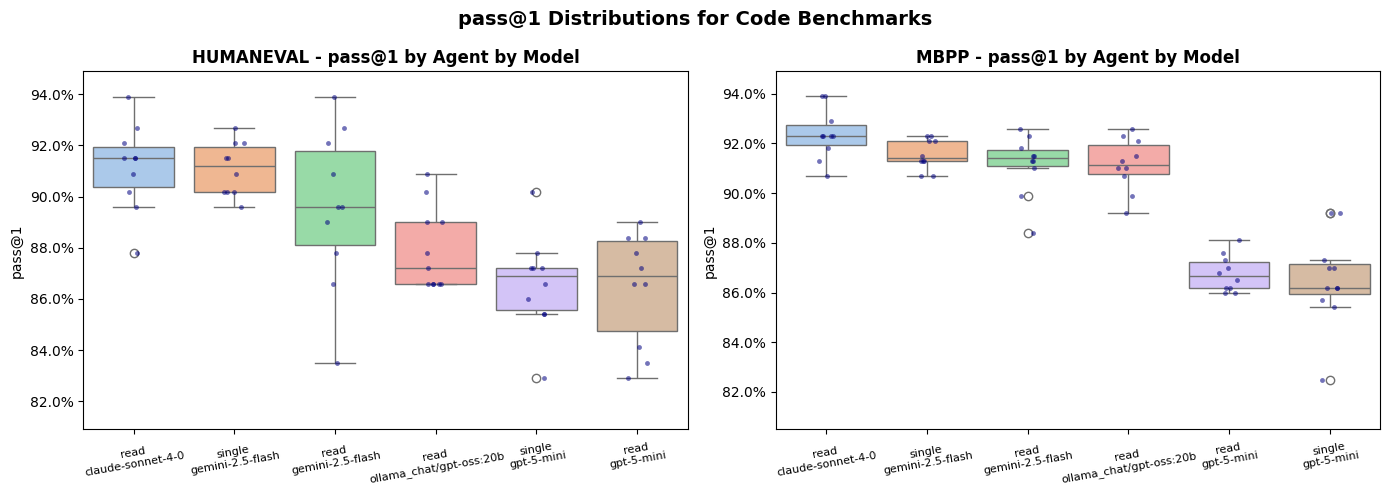

In [100]:
# Box and strip plots: pass@1 by model and dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, dataset in zip(axes, ['humaneval', 'mbpp']):
    sub = df_code[df_code['benchmark'] == dataset].copy()
    sub['agent_model'] = sub['agent'].str.replace('_agent', '') + '\n' + sub['model']
    order = sub.groupby('agent_model')['pass_at_1'].mean().sort_values(ascending=False).index

    sns.boxplot(data=sub, x='agent_model', y='pass_at_1', order=order,
                palette='pastel', linewidth=1, ax=ax)
    sns.stripplot(data=sub, x='agent_model', y='pass_at_1', order=order,
                color='navy', size=3.5, jitter=True, alpha=0.55, ax=ax)

    ax.set_title(f'{dataset.upper()} - pass@1 by Agent by Model', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('pass@1')
    ax.tick_params(axis='x', rotation=10, labelsize=8)
    ax.set_ylim(sub['pass_at_1'].min() - 0.02, sub['pass_at_1'].max() + 0.01)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

plt.suptitle('pass@1 Distributions for Code Benchmarks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Distribution of Design Metrics (LLM-as-a-Judge and RAGAS)

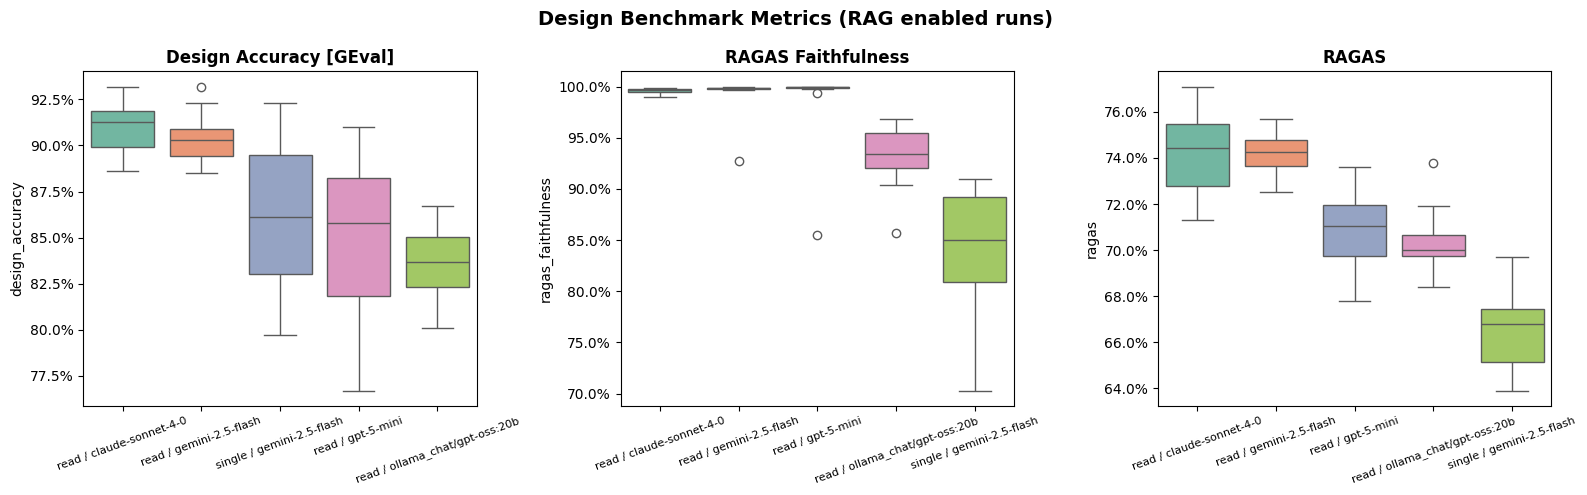

In [101]:
# Box plot of design_accuracy by agent and model
df_bm_rag = df_bm[df_bm['rag'] == True].copy()
df_bm_rag['agent_model'] = df_bm_rag['agent'].str.replace('_agent', '') + ' / ' + df_bm_rag['model']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('design_accuracy', 'Design Accuracy [GEval]'),
        ('ragas_faithfulness', 'RAGAS Faithfulness'),
        ('ragas', 'RAGAS')]

for ax, (metric, title) in zip(axes, metrics):
    order = (df_bm_rag.groupby('agent_model')[metric]
            .mean().sort_values(ascending=False).index)
    sns.boxplot(data=df_bm_rag, x='agent_model', y=metric, order=order,
                palette='Set2', linewidth=1, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

plt.suptitle('Design Benchmark Metrics (RAG enabled runs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### READ-MAS Agents vs Plain LLM in Code Generation

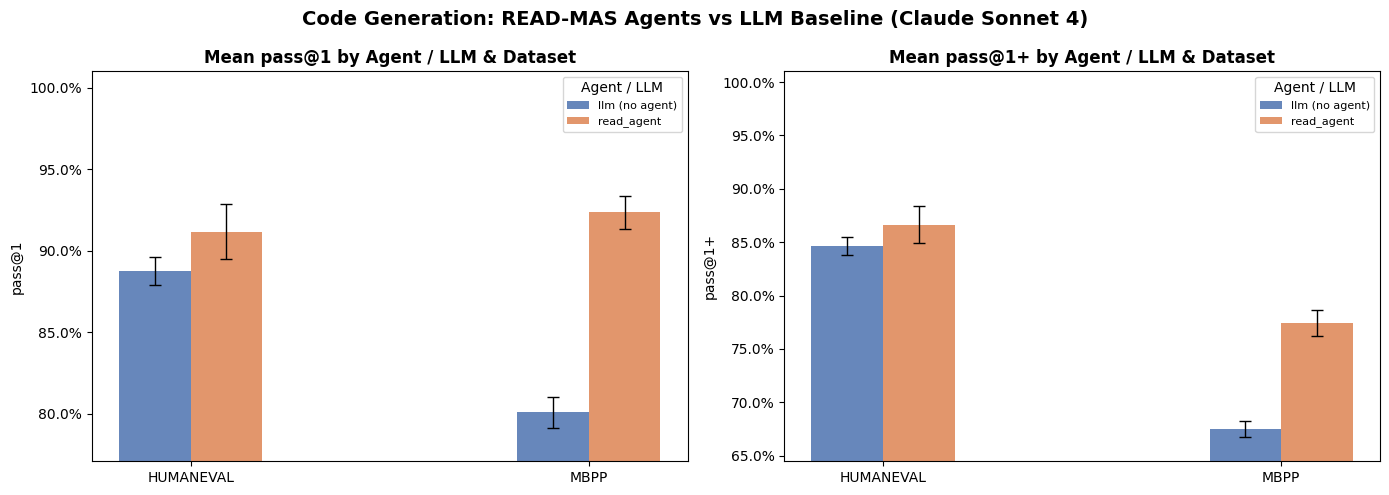

In [102]:
# Grouped bar chart of mean and std of metrics comparing code benchmarks for agent vs LLM use case (RQ4)
# First combine the agent and LLM datasets, selecting only the required model used (Claude) & columns
df_llm_plot = df_llm.copy()
df_llm_plot['agent'] = 'llm (no agent)'
df_code = df_code.copy()
df_code_claude = df_code[df_code['model'] == 'claude-sonnet-4-0']

df_code_llm = pd.concat([
    df_code_claude[['agent', 'model', 'benchmark', 'pass_at_1', 'pass_at_1plus']],
    df_llm_plot[['agent', 'model', 'benchmark', 'pass_at_1', 'pass_at_1plus']],
], ignore_index=True)

# Calculate aggregates for each agent/llm & benchmark category
agg = (df_code_llm
    .groupby(['agent', 'benchmark'])[['pass_at_1', 'pass_at_1plus']]
    .agg(['mean', 'std'])
    .reset_index())
agg.columns = ['agent', 'benchmark', 'p1_mean', 'p1_std', 'p1p_mean', 'p1p_std']

datasets = agg['benchmark'].unique()
agents   = agg['agent'].unique()
x        = np.arange(len(datasets))
width    = 0.18
offsets  = np.linspace(-(len(agents)-1)*width/2, (len(agents)-1)*width/2, len(agents))
colors   = sns.color_palette('deep', len(agents))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, metric, label in zip(axes, ['p1_mean', 'p1p_mean'], ['pass@1', 'pass@1+']):
    std_col = metric.replace('mean', 'std')
    for i, (agent, color) in enumerate(zip(agents, colors)):
        sub = agg[agg['agent'] == agent]
        vals = [sub[sub['benchmark'] == d][metric].values[0] if len(sub[sub['benchmark'] == d]) else np.nan for d in datasets]
        stds = [sub[sub['benchmark'] == d][std_col].values[0] if len(sub[sub['benchmark'] == d]) else 0 for d in datasets]
        ax.bar(x + offsets[i], vals, width, yerr=stds, label=agent,
            color=color, alpha=0.85, capsize=4, error_kw={'linewidth': 1})

    ax.set_xticks(x); ax.set_xticklabels([d.upper() for d in datasets])
    ax.set_title(f'Mean {label} by Agent / LLM & Dataset', fontweight='bold')
    ax.set_ylabel(label)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    lo = agg[[metric]].min().min() - 0.03
    ax.set_ylim(max(0, lo), 1.01)
    ax.legend(title='Agent / LLM', fontsize=8, loc='upper right')

plt.suptitle('Code Generation: READ-MAS Agents vs LLM Baseline (Claude Sonnet 4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Effect of RAG on Design Accuracy

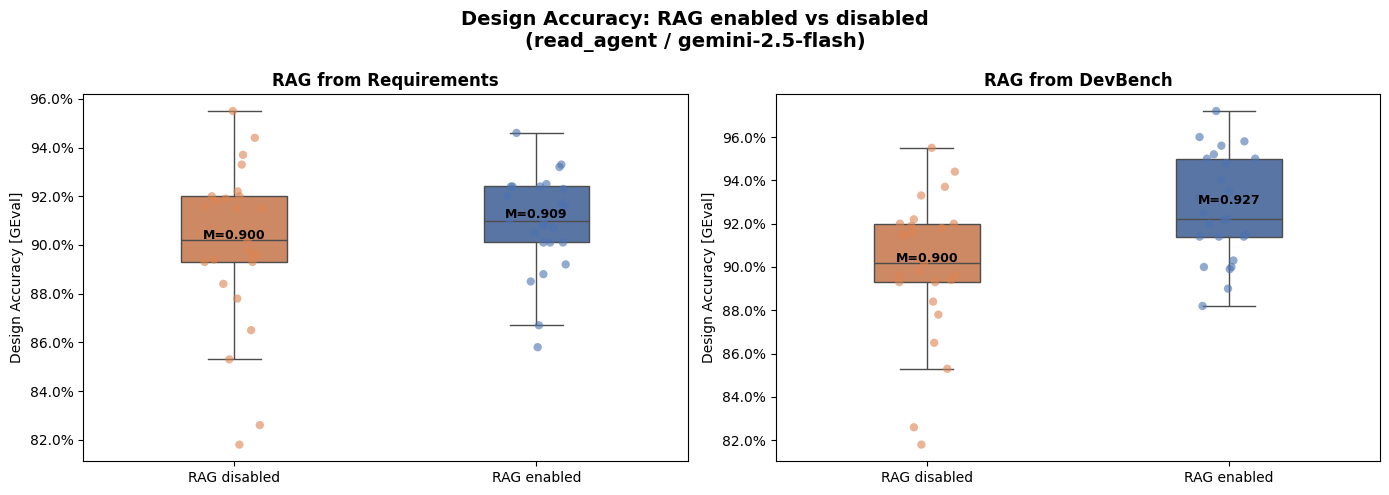

In [104]:
# Box and strip plots for design_accuracy with vs without RAG

df_bm_rag['RAG'] = df_bm_rag['rag'].map({True: 'RAG enabled', False: 'RAG disabled'})
df_bm_rag_specific['RAG'] = df_bm_rag_specific['rag'].map({True: 'RAG enabled', False: 'RAG disabled'})

order_rag = ['RAG disabled', 'RAG enabled']
palette_rag = {'RAG enabled': '#4C72B0', 'RAG disabled': '#DD8452'}
sub_titles = ['RAG from Requirements', 'RAG from DevBench']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, data, sub_title in zip(axes, [df_bm_rag, df_bm_rag_specific], sub_titles):
    sns.boxplot(data=data, x='RAG', y='design_accuracy', order=order_rag,
                palette=palette_rag, width=0.35, fliersize=0, ax=ax)
    sns.stripplot(data=data, x='RAG', y='design_accuracy', order=order_rag,
                palette=palette_rag, size=6, jitter=True, alpha=0.6, ax=ax)

    # Annotate means
    for i, label in enumerate(order_rag):
        vals = data[data['RAG'] == label]['design_accuracy']
        ax.text(i, vals.mean() + 0.002, f'M={vals.mean():.3f}', ha='center',
                fontsize=9, color='black', fontweight='bold')

    ax.set_title(sub_title,
                fontweight='bold')
    ax.set_ylabel('Design Accuracy [GEval]')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_xlabel('')

plt.suptitle('Design Accuracy: RAG enabled vs disabled\n(read_agent / gemini-2.5-flash)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## EDA of Agent-Level Training and Evaluation Datasets

EDA for per-agent training runs (prompt optimisation iterations) and post-optimisation evaluation runs.

### Data Constants

In [88]:
# Common column renaming maps for trainign and eval datasets
RENAME_TRAIN_COMMON = {
  'runs/train_runs/metrics.json:agent':                           'agent',
  'RequirementsAccuracy [GEval]':                                 'requirements_accuracy',
  'runs/train_runs/metrics.json:RequirementsAccuracy [GEval]':    'requirements_accuracy',
  'AnalysisAccuracy [GEval]':                                     'analysis_accuracy',
  'runs/train_runs/metrics.json:AnalysisAccuracy [GEval]':        'analysis_accuracy',
  'SpecificationAccuracy [GEval]':                                'specification_accuracy',
  'runs/train_runs/metrics.json:SpecificationAccuracy [GEval]':   'specification_accuracy',
  'DesignerAccuracy [GEval]':                                     'designer_accuracy',
  'runs/train_runs/metrics.json:DesignerAccuracy [GEval]':        'designer_accuracy',
  'DesignDocumentAccuracy [GEval]':                               'design_document_accuracy',
  'runs/train_runs/metrics.json:DesignDocumentAccuracy [GEval]':  'design_document_accuracy',
  'runs/train_runs/metrics.json:DesignAccuracy [GEval]':          'design_accuracy',
  'Hallucination':                                                'hallucination',
  'runs/train_runs/metrics.json:Hallucination':                   'hallucination',
  'runs/train_runs/metrics.json:faithfulness (ragas)':            'ragas_faithfulness',
  'runs/train_runs/metrics.json:RAGAS':                           'ragas',
}

RENAME_EVAL_COMMON = {
  'runs/eval_runs/metrics.json:agent':                            'agent',
  'runs/eval_runs/metrics.json:RequirementsAccuracy [GEval]':     'requirements_accuracy',
  'runs/eval_runs/metrics.json:AnalysisAccuracy [GEval]':         'analysis_accuracy',
  'runs/eval_runs/metrics.json:SpecificationAccuracy [GEval]':    'specification_accuracy',
  'runs/eval_runs/metrics.json:DesignerAccuracy [GEval]':         'designer_accuracy',
  'runs/eval_runs/metrics.json:DesignDocumentAccuracy [GEval]':   'design_document_accuracy',
  'runs/eval_runs/metrics.json:DesignAccuracy [GEval]':           'design_accuracy',
  'runs/eval_runs/metrics.json:Hallucination':                    'hallucination',
  'runs/eval_runs/metrics.json:faithfulness (ragas)':             'ragas_faithfulness',
  'runs/eval_runs/metrics.json:RAGAS':                            'ragas',
}

# Per-agent keep-column lists
COLLECTOR_COLS   = ['agent', 'requirements_accuracy', 'hallucination', 'ragas_faithfulness', 'ragas', 'no_opt']
ANALYZER_COLS    = ['agent', 'analysis_accuracy', 'no_opt']
SPECIFIER_COLS   = ['agent', 'specification_accuracy', 'hallucination', 'no_opt']
DESIGNER_COLS    = ['agent', 'designer_accuracy', 'hallucination', 'no_opt']
DOCUMENTER_COLS  = ['agent', 'design_document_accuracy', 'no_opt']
READ_AGENT_COLS  = ['agent', 'design_accuracy', 'ragas_faithfulness', 'ragas']
SINGLE_AGENT_COLS = ['agent', 'design_accuracy', 'ragas_faithfulness', 'ragas']

# Training file groups and col-metrics map
EDA_TRAIN_FILES = {
  'collector_agent':  ('collector_agent_train.csv',),
  'analyzer_agent':   ('analyzer_agent_train.csv',),
  'specifier_agent':  ('specifier_agent_train.csv',),
  'designer_agent':   ('designer_agent_train.csv',),
  'documenter_agent': ('documenter_agent_train.csv',),
  'read_agent':       ('read_agent_train.csv',),
  'single_agent':     ('single_agent_train.csv',),
}

EDA_TRAIN_COL_METRICS_MAP = {
  'collector_agent': {'rename_cols': RENAME_TRAIN_COMMON, 'keep_cols': COLLECTOR_COLS,    'metrics': ['requirements_accuracy', 'hallucination']},
  'analyzer_agent': {'rename_cols': RENAME_TRAIN_COMMON, 'keep_cols': ANALYZER_COLS,     'metrics': ['analysis_accuracy']},
  'specifier_agent': {'rename_cols': RENAME_TRAIN_COMMON, 'keep_cols': SPECIFIER_COLS,    'metrics': ['specification_accuracy', 'hallucination']},
  'designer_agent': {'rename_cols': RENAME_TRAIN_COMMON, 'keep_cols': DESIGNER_COLS,     'metrics': ['designer_accuracy', 'hallucination']},
  'documenter_agent': {'rename_cols': RENAME_TRAIN_COMMON, 'keep_cols': DOCUMENTER_COLS,   'metrics': ['design_document_accuracy']},
  'read_agent': {'rename_cols': RENAME_TRAIN_COMMON, 'keep_cols': READ_AGENT_COLS,   'metrics': ['design_accuracy']},
  'single_agent': {'rename_cols': RENAME_TRAIN_COMMON, 'keep_cols': SINGLE_AGENT_COLS, 'metrics': ['design_accuracy']},
}

# Eval file groups and col-metrics map
EDA_EVAL_FILES = {
  'collector_agent':  ('collector_agent_eval.csv',),
  'analyzer_agent':   ('analyzer_agent_eval.csv',),
  'specifier_agent':  ('specifier_agent_eval.csv',),
  'designer_agent':   ('designer_agent_eval.csv',),
  'documenter_agent': ('documenter_agent_eval.csv',),
  'read_agent':       ('read_agent_eval.csv',),
  'single_agent':     ('single_agent_eval.csv',),
}

EDA_EVAL_COL_METRICS_MAP = {
  'collector_agent':  {'rename_cols': RENAME_EVAL_COMMON, 'keep_cols': COLLECTOR_COLS[:-1],    'metrics': ['requirements_accuracy', 'hallucination']},
  'analyzer_agent':   {'rename_cols': RENAME_EVAL_COMMON, 'keep_cols': ANALYZER_COLS[:-1],     'metrics': ['analysis_accuracy']},
  'specifier_agent':  {'rename_cols': RENAME_EVAL_COMMON, 'keep_cols': SPECIFIER_COLS[:-1],    'metrics': ['specification_accuracy', 'hallucination']},
  'designer_agent':   {'rename_cols': RENAME_EVAL_COMMON, 'keep_cols': DESIGNER_COLS[:-1],     'metrics': ['designer_accuracy', 'hallucination']},
  'documenter_agent': {'rename_cols': RENAME_EVAL_COMMON, 'keep_cols': DOCUMENTER_COLS[:-1],   'metrics': ['design_document_accuracy']},
  'read_agent':       {'rename_cols': RENAME_EVAL_COMMON, 'keep_cols': READ_AGENT_COLS,        'metrics': ['design_accuracy']},
  'single_agent':     {'rename_cols': RENAME_EVAL_COMMON, 'keep_cols': SINGLE_AGENT_COLS,      'metrics': ['design_accuracy']},
}

# Maps each agent to its accuracy metric name
AGENT_ACCURACY_MAP = {
  'collector_agent':  'requirements_accuracy',
  'analyzer_agent':   'analysis_accuracy',
  'specifier_agent':  'specification_accuracy',
  'designer_agent':   'designer_accuracy',
  'documenter_agent': 'design_document_accuracy',
  'read_agent':       'design_accuracy',
  'single_agent':     'design_accuracy',
}

### Data Loading for the Train/Eval Datasets

In [89]:
# Train / Eval grouped datasets (per agent)
eda_train_group_dfs = get_group_dfs(EDA_TRAIN_FILES, EDA_TRAIN_COL_METRICS_MAP)
eda_eval_group_dfs  = get_group_dfs(EDA_EVAL_FILES,  EDA_EVAL_COL_METRICS_MAP)

### Create Agent Train and Eval Data Frames

In [90]:
#Create train and eval data frames by combining their respective agent group dfs
def create_agent_dfs(group_dfs):
  """Concat per-agent group_dfs, fix agent name and derive agent accuracy metric.
  
  Args:
    group_dfs: train or eval grouped data frames
    
  Returns:
    concatenated agent-level data frames
  """
  agent_dfs = []
  for group in group_dfs:
    df = group['group_df'].copy()
    # Override load_experiment_dataset agent values for single agent use cases
    if 'agent' not in df.columns or df['agent'].isna().all():
      df['agent'] = group['benchmark']
    df.loc[df['agent'] == 'llm', 'agent'] = group['benchmark']
    acc_col = AGENT_ACCURACY_MAP.get(group['benchmark'])
    df['primary_accuracy'] = df[acc_col] if (acc_col and acc_col in df.columns) else np.nan
    # Normalize no_opt to boolean True or False values
    if 'no_opt' in df.columns:
      df['no_opt'] = df['no_opt'].map(lambda v: True if str(v) == 'True' else (False if str(v) == 'False' else np.nan))
    agent_dfs.append(df)
  return pd.concat(agent_dfs, ignore_index=True)

df_train = create_agent_dfs(eda_train_group_dfs)
df_eval  = create_agent_dfs(eda_eval_group_dfs)

### Dataset Overview

In [91]:
# Combine train and eval data frames to run execution counts by agent by split
df_train['split'] = 'train'
df_eval['split']  = 'eval'
df_all = pd.concat([df_train, df_eval], ignore_index=True)

# Coerce metric columns to numeric data type
metric_cols = ['primary_accuracy', 'hallucination', 'ragas_faithfulness', 'ragas']
for col in metric_cols:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

counts = df_all.groupby(['agent', 'split']).size().unstack(fill_value=0)
counts['total'] = counts.sum(axis=1)
print('## Execution counts per agent')
print(counts.to_markdown())


## Execution counts per agent
| agent            |   eval |   train |   total |
|:-----------------|-------:|--------:|--------:|
| analyzer_agent   |      5 |       4 |       9 |
| collector_agent  |      7 |       5 |      12 |
| designer_agent   |      5 |       4 |       9 |
| documenter_agent |      5 |       3 |       8 |
| read_agent       |      5 |       3 |       8 |
| single_agent     |      4 |       5 |       9 |
| specifier_agent  |      5 |       4 |       9 |


### Agent Accuracy: Train vs Eval per Agent

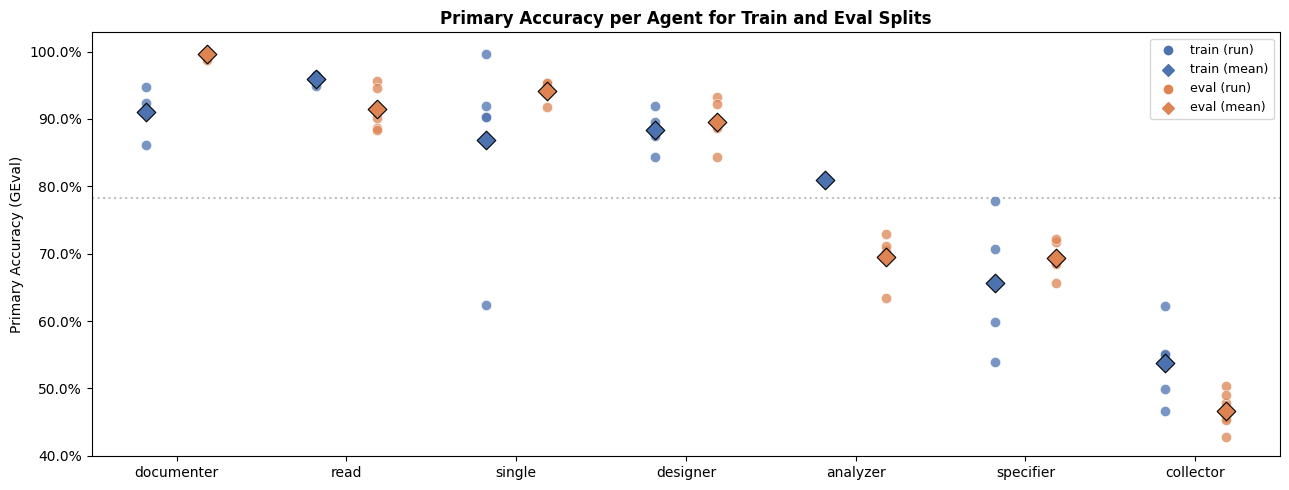

| agent            |   ('count', 'eval') |   ('count', 'train') |   ('mean', 'eval') |   ('mean', 'train') |   ('std', 'eval') |   ('std', 'train') |   ('min', 'eval') |   ('min', 'train') |   ('max', 'eval') |   ('max', 'train') |
|:-----------------|--------------------:|---------------------:|-------------------:|--------------------:|------------------:|-------------------:|------------------:|-------------------:|------------------:|-------------------:|
| analyzer_agent   |                   5 |                    4 |              0.695 |               0.81  |             0.036 |              0.003 |             0.635 |              0.807 |             0.729 |              0.812 |
| collector_agent  |                   7 |                    5 |              0.467 |               0.538 |             0.026 |              0.06  |             0.428 |              0.466 |             0.503 |              0.623 |
| designer_agent   |                   5 |                    4 |       

In [92]:
# Agent primary accuracy scatter plot (with mean markers) and summary statistics table by agent by train/eval
agent_order = (df_all.groupby('agent')['primary_accuracy']
            .mean().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(13, 5))
palette_split = {'train': '#4C72B0', 'eval': '#DD8452'}
jitter_map    = {'train': -0.18, 'eval': 0.18}
x_pos = {a: i for i, a in enumerate(agent_order)}

for split, color in palette_split.items():
    sub = df_all[df_all['split'] == split].dropna(subset=['primary_accuracy'])
    for agent, grp in sub.groupby('agent'):
        x = x_pos[agent] + jitter_map[split]
        ax.scatter([x] * len(grp), grp['primary_accuracy'],
                color=color, alpha=0.75, s=55, zorder=3,
                edgecolors='white', linewidth=0.5)
        # Mean marker
        ax.scatter([x], [grp['primary_accuracy'].mean()],
                color=color, marker='D', s=90, zorder=4,
                edgecolors='black', linewidth=0.8)

ax.set_xticks(range(len(agent_order)))
ax.set_xticklabels([a.replace('_agent', '') for a in agent_order], fontsize=10)
ax.set_ylabel('Primary Accuracy (GEval)')
ax.set_title('Primary Accuracy per Agent for Train and Eval Splits', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

legend_elements = [
    plt.scatter([], [], color='#4C72B0', marker='o', label='train (run)'),
    plt.scatter([], [], color='#4C72B0', marker='D', label='train (mean)'),
    plt.scatter([], [], color='#DD8452', marker='o', label='eval (run)'),
    plt.scatter([], [], color='#DD8452', marker='D', label='eval (mean)'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
ax.axhline(df_all['primary_accuracy'].mean(), color='grey', linestyle=':', alpha=0.5)
ax.set_xlim(-0.5, len(agent_order) - 0.5)
plt.tight_layout()
plt.show()

# Numeric summary
summary = (df_all.groupby(['agent', 'split'])['primary_accuracy']
        .agg(['count', 'mean', 'std', 'min', 'max'])
        .round(3)
        .unstack('split'))
print(summary.to_markdown())


### Hallucination Rates per Agent

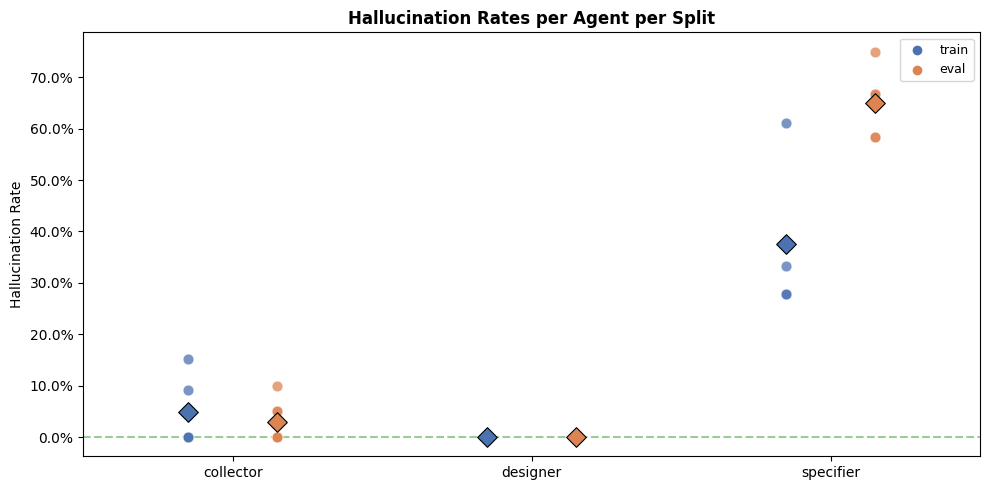


## Hallucination Rates per Agent per Split
|                              |   count |   mean |   std |   min |   max |
|:-----------------------------|--------:|-------:|------:|------:|------:|
| ('collector_agent', 'eval')  |       7 |  0.029 | 0.039 | 0     | 0.1   |
| ('collector_agent', 'train') |       5 |  0.049 | 0.07  | 0     | 0.152 |
| ('designer_agent', 'eval')   |       5 |  0     | 0     | 0     | 0     |
| ('designer_agent', 'train')  |       4 |  0     | 0     | 0     | 0     |
| ('specifier_agent', 'eval')  |       5 |  0.65  | 0.07  | 0.583 | 0.75  |
| ('specifier_agent', 'train') |       4 |  0.375 | 0.159 | 0.278 | 0.611 |


In [93]:
# Scatter plot and summary statistics table for agent hallucination rates by split
df_hallucination = df_all.dropna(subset=['hallucination'])
if len(df_hallucination) == 0:
  print('No hallucination data available.')
else:
  agents_hallucinations = df_hallucination['agent'].unique()
  fig, ax = plt.subplots(figsize=(10, 5))
  palette_split = {'train': '#4C72B0', 'eval': '#DD8452'}
  jitter_map    = {'train': -0.15, 'eval': 0.15}
  x_pos = {a: i for i, a in enumerate(sorted(agents_hallucinations))}

  for split, color in palette_split.items():
    sub = df_hallucination[df_hallucination['split'] == split]
    for agent, grp in sub.groupby('agent'):
      x = x_pos[agent] + jitter_map[split]
      ax.scatter([x] * len(grp), grp['hallucination'],
                color=color, alpha=0.75, s=60, zorder=3,
                edgecolors='white', linewidth=0.5)
      ax.scatter([x], [grp['hallucination'].mean()],
                color=color, marker='D', s=100, zorder=4,
                edgecolors='black', linewidth=0.8)

  ax.set_xticks(list(x_pos.values()))
  ax.set_xticklabels([a.replace('_agent', '') for a in sorted(agents_hallucinations)], fontsize=10)
  ax.set_ylabel('Hallucination Rate')
  ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
  ax.set_title('Hallucination Rates per Agent per Split', fontweight='bold')
  ax.axhline(0, color='green', linestyle='--', alpha=0.4, label='zero hallucination')
  legend_elements = [
    plt.scatter([], [], color='#4C72B0', marker='o', label='train'),
    plt.scatter([], [], color='#DD8452', marker='o', label='eval'),
  ]
  ax.legend(handles=legend_elements, fontsize=9)
  ax.set_xlim(-0.5, len(agents_hallucinations) - 0.5)
  plt.tight_layout()
  plt.show()

  print('\n## Hallucination Rates per Agent per Split')
  print(df_hallucination.groupby(['agent', 'split'])['hallucination']
          .agg(['count', 'mean', 'std', 'min', 'max']).round(3).to_markdown())


### Effect of Prompt Optimization on Training Accuracy

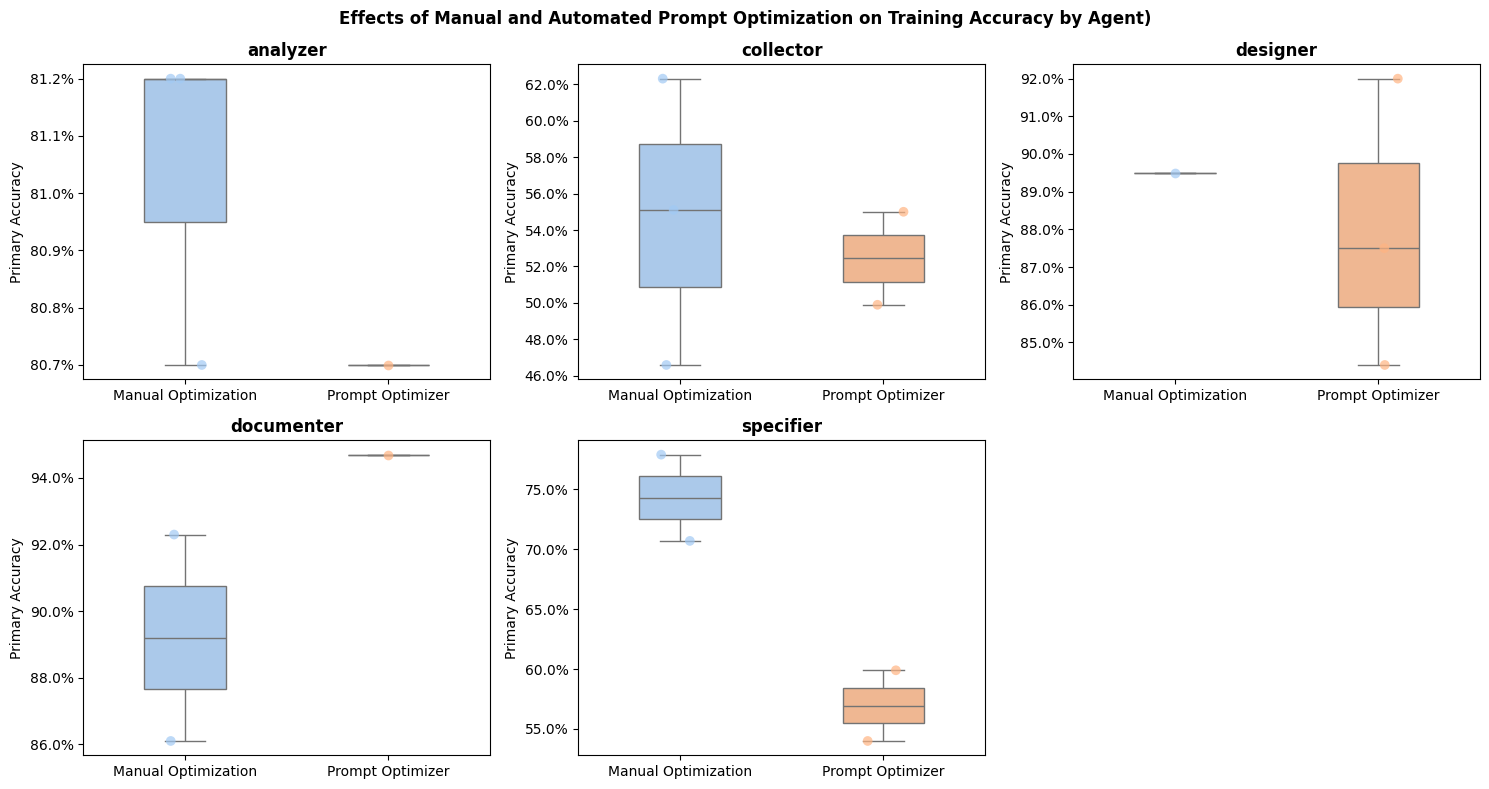

In [94]:
# Strip and box plots for agent training primary_accuracy split by no_opt flag
df_opt = df_train.dropna(subset=['primary_accuracy', 'no_opt']).copy()
df_opt['Optimized'] = df_opt['no_opt'].map({True: 'Manual Optimization',
                                            False: 'Prompt Optimizer'})

agents_with_opt = df_opt['agent'].unique()
ncols = min(3, len(agents_with_opt))
nrows = -(-len(agents_with_opt) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=False)
axes = np.array(axes).flatten()

opt_order   = ['Manual Optimization', 'Prompt Optimizer']

for ax, agent in zip(axes, sorted(agents_with_opt)):
  sub = df_opt[df_opt['agent'] == agent]
  sns.boxplot(data=sub, x='Optimized', y='primary_accuracy',
              order=opt_order, palette='pastel', width=0.4,
              fliersize=0, ax=ax)
  sns.stripplot(data=sub, x='Optimized', y='primary_accuracy',
                order=opt_order, palette='pastel',
                size=7, jitter=True, alpha=0.7, ax=ax)

  ax.set_title(agent.replace('_agent', ''), fontweight='bold')
  ax.set_xlabel('')
  ax.set_ylabel('Primary Accuracy')
  ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

for ax in axes[len(agents_with_opt):]:
  ax.axis('off')

plt.suptitle('Effects of Manual and Automated Prompt Optimization on Training Accuracy by Agent)',
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### RAGAS and RAGAS Faithfulness Metrics for End-to-End Agents

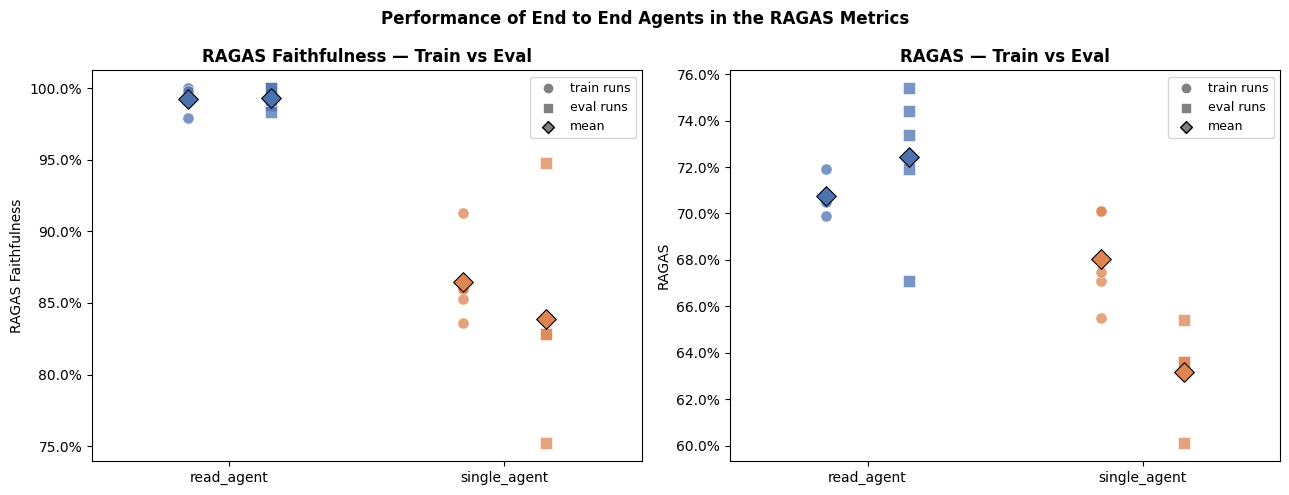


## Summary Statistics for the RAGAS Metrics
|                           |   ('ragas_faithfulness', 'count') |   ('ragas_faithfulness', 'mean') |   ('ragas_faithfulness', 'std') |   ('ragas', 'count') |   ('ragas', 'mean') |   ('ragas', 'std') |
|:--------------------------|----------------------------------:|---------------------------------:|--------------------------------:|---------------------:|--------------------:|-------------------:|
| ('read_agent', 'eval')    |                                 5 |                            0.993 |                           0.008 |                    5 |               0.724 |              0.033 |
| ('read_agent', 'train')   |                                 3 |                            0.992 |                           0.012 |                    3 |               0.708 |              0.01  |
| ('single_agent', 'eval')  |                                 4 |                            0.839 |                           0.081 |                 

In [95]:
# Strip plots for ragas_faithfulness and ragas metrics for read_agent and single_agent
e2e_agents = ['read_agent', 'single_agent']
df_ragas = df_all[df_all['agent'].isin(e2e_agents)].copy()
df_ragas = df_ragas.dropna(subset=['ragas_faithfulness', 'ragas'], how='all')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette_agent = {'read_agent': '#4C72B0', 'single_agent': '#DD8452'}
jitter_map_split = {'train': -0.15, 'eval': 0.15}

for ax, metric, title in zip(axes,
    ['ragas_faithfulness', 'ragas'],
    ['RAGAS Faithfulness', 'RAGAS']):
  sub = df_ragas.dropna(subset=[metric])
  x_pos = {a: i for i, a in enumerate(e2e_agents)}
  for split in ['train', 'eval']:
    for agent in e2e_agents:
      grp = sub[(sub['agent'] == agent) & (sub['split'] == split)]
      x = x_pos[agent] + jitter_map_split[split]
      color = palette_agent[agent]
      marker = 'o' if split == 'train' else 's'
      ax.scatter([x] * len(grp), grp[metric],
                color=color, marker=marker, alpha=0.75, s=65, zorder=3,
                edgecolors='white', linewidth=0.5)
      ax.scatter([x], [grp[metric].mean()],
                color=color, marker='D', s=100, zorder=4,
                edgecolors='black', linewidth=0.8)

  ax.set_xticks(list(x_pos.values()))
  ax.set_xticklabels(e2e_agents, fontsize=10)
  ax.set_ylabel(title)
  ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
  ax.set_title(f'{title} — Train vs Eval', fontweight='bold')
  ax.set_xlim(-0.5, len(e2e_agents) - 0.5)

  legend_elems = [
    plt.scatter([], [], color='grey', marker='o', label='train runs'),
    plt.scatter([], [], color='grey', marker='s', label='eval runs'),
    plt.scatter([], [], color='grey', marker='D', label='mean', edgecolors='black'),
  ]
  ax.legend(handles=legend_elems, fontsize=9)

plt.suptitle('Performance of End to End Agents in the RAGAS Metrics',
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n## Summary Statistics for the RAGAS Metrics')
print(df_ragas.groupby(['agent', 'split'])[['ragas_faithfulness', 'ragas']]
        .agg(['count', 'mean', 'std']).round(3).to_markdown())
